# Module 3 — Remaining Work only (local VS Code + laptop GPU version)
### DermaVision AI: Skin Pigmentation Detection, Analysis & Future Skin Health Prediction

This notebook is **standalone**: it does *not* retrain the YOLO26-cls baseline. It only runs what was still pending:

| # | Task | Theory topic |
|---|------|--------------|
| 1 | Transfer-learning classifiers: **ResNet50, EfficientNetB0, MobileNetV2** | Transfer Learning |
| 2 | **YOLO object detection** (pseudo bounding boxes) | YOLO localization |
| 3 | **U-Net segmentation** + **pigmentation percentage** per image | U-Net |

**Before running (local setup):**
1. Create a virtual env and select it as the notebook kernel in VS Code (top-right *Select Kernel*).
2. Install a **CUDA build of PyTorch first** (see the markdown cell below) — a plain `pip install torch` on Windows gives a CPU-only build.
3. Run the next cell; it checks that PyTorch can see your GPU, then installs the remaining packages.

All outputs go to `./working` next to this notebook. Batch size, AMP (mixed precision) and DataLoader workers are chosen automatically from your GPU's VRAM and OS.

**Note on Parts 2 & 3:** the dataset has only image-level labels (no boxes/masks), so pseudo labels are generated with LAB-colour thresholding (*weak supervision*). Mention this in your report/viva.

**Optional:** if you still have the old `working/yolo_runs/baseline_224/weights/best.pt`, the comparison cell in Part 1 will include it. If not, that cell is skipped automatically.

## Step −1 — One-time environment setup (run in a terminal, not in the notebook)

```bash
# Windows (PowerShell)                       # Linux / macOS
python -m venv .venv                         python3 -m venv .venv
.venv\Scripts\Activate.ps1                   source .venv/bin/activate

# NVIDIA GPU — install CUDA PyTorch FIRST (pick the CUDA version shown at https://pytorch.org/get-started/locally/)
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

# then the rest
pip install -r requirements.txt
```

Check your driver with `nvidia-smi` in a terminal. Then in VS Code: *Select Kernel → Python Environments → .venv*.


In [1]:
# Guard: make sure a GPU-enabled PyTorch is present BEFORE installing ultralytics,
# otherwise pip may pull a CPU-only torch as a dependency.
import importlib.util, shutil, sys, subprocess

if importlib.util.find_spec("torch") is None:
    raise RuntimeError(
        "PyTorch is not installed in this kernel. Install the CUDA build first "
        "(see the setup cell above), then re-run this cell."
    )

import torch
has_nvidia = shutil.which("nvidia-smi") is not None
if has_nvidia and not torch.cuda.is_available():
    raise RuntimeError(
        f"An NVIDIA GPU was found but this PyTorch ({torch.__version__}) is CPU-only. "
        "Reinstall with: pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 "
        "(then restart the kernel)."
    )

%pip install -q -U ultralytics imagehash kagglehub seaborn scikit-learn opencv-python pillow pandas matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# SETUP  (local machine / laptop GPU)
# ============================================================
import os
from pathlib import Path

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

import torch

# Outputs go next to the notebook (VS Code's working dir is the notebook folder by default)
BASE_DIR = Path("./working").resolve()
BASE_DIR.mkdir(parents=True, exist_ok=True)

# ---- device selection: CUDA -> Apple MPS -> CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    YOLO_DEVICE = 0
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    YOLO_DEVICE = "mps"
else:
    DEVICE = torch.device("cpu")
    YOLO_DEVICE = "cpu"

# ---- performance / memory settings tuned for laptop GPUs
USE_AMP = DEVICE.type == "cuda"          # mixed precision: ~2x less VRAM, faster on RTX cards
PIN_MEMORY = DEVICE.type == "cuda"
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
else:
    vram_gb = 0.0

# Windows + notebooks + multiprocessing DataLoader workers is fragile -> use 0 there
NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)

# Batch sizes scaled to VRAM (lower these if you hit "CUDA out of memory")
if vram_gb and vram_gb < 5:
    BATCH_SIZE, SEG_BATCH = 16, 8
elif vram_gb and vram_gb < 7:
    BATCH_SIZE, SEG_BATCH = 32, 16
elif vram_gb:
    BATCH_SIZE, SEG_BATCH = 64, 16
else:
    BATCH_SIZE, SEG_BATCH = 16, 8
YOLO_BATCH = BATCH_SIZE

print("Base directory :", BASE_DIR)
print("PyTorch        :", torch.__version__, "| CUDA build:", torch.version.cuda)
print("Device         :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU            :", torch.cuda.get_device_name(0), f"| {vram_gb:.1f} GB VRAM")
print("AMP            :", USE_AMP)
print("Workers        :", NUM_WORKERS)
print(f"Batch sizes    : classifiers={BATCH_SIZE}, U-Net={SEG_BATCH}, YOLO={YOLO_BATCH}")

Base directory : D:\nn\working
PyTorch        : 2.11.0+cu128 | CUDA build: 12.8
Device         : cuda
GPU            : NVIDIA GeForce RTX 3050 6GB Laptop GPU | 6.0 GB VRAM
AMP            : True
Workers        : 0
Batch sizes    : classifiers=32, U-Net=16, YOLO=32


In [3]:
# ============================================================
# PROJECT SETUP
# ============================================================

import os
import shutil
import random
import json
import math
import gc
from pathlib import Path

# ------------------------------------------------------------
# Core libraries
# ------------------------------------------------------------

import numpy as np

# Pandas
try:
    import pandas as pd
    print("Pandas imported successfully")
except ImportError as e:
    print("\n❌ Pandas import failed!")
    print(e)
    print("\nThis is an environment/DLL problem, not a problem")
    print("with the ML code below.")
    raise

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Image processing
# ------------------------------------------------------------

import cv2
from PIL import Image

# ------------------------------------------------------------
# PyTorch
# ------------------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from torchvision.datasets import ImageFolder

# ------------------------------------------------------------
# Scikit-learn
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# YOLO
# ------------------------------------------------------------

from ultralytics import YOLO

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)

print("Python environment :", os.environ.get("VIRTUAL_ENV", "Unknown"))
print("NumPy version      :", np.__version__)
print("Pandas version     :", pd.__version__)
print("PyTorch version    :", torch.__version__)
print("CUDA available     :", torch.cuda.is_available())
print("Device             :", DEVICE)

if torch.cuda.is_available():
    print("GPU                :", torch.cuda.get_device_name(0))

print("=" * 60)
print("✅ Imports completed successfully")
print("=" * 60)

Pandas imported successfully
ENVIRONMENT CHECK
Python environment : D:\nn\.venv311
NumPy version      : 2.4.6
Pandas version     : 3.0.6
PyTorch version    : 2.11.0+cu128
CUDA available     : True
Device             : cuda
GPU                : NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ Imports completed successfully


## Step 0 — Prepare the train/val class folders (fast, no training)
Downloads the Kaggle dataset, drops corrupt images and builds `skin_yolo_dataset/{train,val}/<class>/` — the same split your earlier notebook used. Skipped automatically if it already exists.

In [4]:
# ============================================================
# SKIN DISEASE DATASET PREPARATION
# ============================================================

import os
import shutil
from pathlib import Path

# ------------------------------------------------------------
# 1. Configure storage on D: drive
# ------------------------------------------------------------
os.environ["KAGGLEHUB_CACHE"] = r"D:\kaggle_cache"
os.environ["TEMP"] = r"D:\temp"
os.environ["TMP"] = r"D:\temp"

Path(r"D:\kaggle_cache").mkdir(parents=True, exist_ok=True)
Path(r"D:\temp").mkdir(parents=True, exist_ok=True)

# Project directory
BASE_DIR = Path(r"D:\nn")
BASE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Imports
# ------------------------------------------------------------
import kagglehub
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# ------------------------------------------------------------
# 3. Paths
# ------------------------------------------------------------
WORK_DIR = BASE_DIR / "skin_yolo_dataset"

BASELINE_PATH = (
    BASE_DIR / "yolo_runs" / "baseline_224" / "weights" / "best.pt"
)

print("BASE_DIR :", BASE_DIR)
print("WORK_DIR :", WORK_DIR)
print("KaggleHub cache :", os.environ["KAGGLEHUB_CACHE"])

# ------------------------------------------------------------
# 4. Check whether dataset is already prepared
# ------------------------------------------------------------
def _already_prepared():
    return (
        (WORK_DIR / "train").exists()
        and any((WORK_DIR / "train").glob("*/*.*"))
    )


if _already_prepared():

    print("✅ Dataset split already exists — skipping preparation.")

else:

    # --------------------------------------------------------
    # 5. Download dataset
    # --------------------------------------------------------
    print("\nDownloading dataset...")
    
    dataset_path = kagglehub.dataset_download(
        "mgmitesh/skin-disease-detection-dataset"
    )

    print("✅ Dataset downloaded to:")
    print(dataset_path)

    # --------------------------------------------------------
    # 6. Supported image formats
    # --------------------------------------------------------
    IMAGE_EXTENSIONS = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".webp",
        ".tif",
        ".tiff"
    }

    # --------------------------------------------------------
    # 7. Detect train/validation/test split
    # --------------------------------------------------------
    def detect_split(path):

        lower = [p.lower() for p in Path(path).parts]

        for name, mapped in [
            ("train", "train"),
            ("val", "val"),
            ("valid", "val"),
            ("test", "test")
        ]:

            if name in lower:
                return mapped

        return "unknown"

    # --------------------------------------------------------
    # 8. Detect class name
    # --------------------------------------------------------
    def get_class_from_path(path):

        parts = list(Path(path).parts)
        lower = [p.lower() for p in parts]

        for split_name in [
            "train",
            "val",
            "valid",
            "test"
        ]:

            if split_name in lower:

                idx = lower.index(split_name)

                if idx + 1 < len(parts):
                    return parts[idx + 1]

        return Path(path).parent.name

    # --------------------------------------------------------
    # 9. Remove previous incomplete preparation
    # --------------------------------------------------------
    if WORK_DIR.exists():

        print("\nRemoving previous incomplete dataset...")

        shutil.rmtree(WORK_DIR)

    # --------------------------------------------------------
    # 10. Counters
    # --------------------------------------------------------
    copied = {
        "train": 0,
        "val": 0
    }

    skipped_corrupt = 0

    # --------------------------------------------------------
    # 11. Process images
    # --------------------------------------------------------
    print("\nPreparing dataset...")

    for path in Path(dataset_path).rglob("*"):

        # Skip non-image files
        if not (
            path.is_file()
            and path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            continue

        # Detect split
        split = detect_split(path)

        # We only prepare train and validation
        if split not in copied:
            continue

        # ----------------------------------------------------
        # Verify image
        # ----------------------------------------------------
        try:

            with Image.open(path) as im:
                im.verify()

        except Exception:

            skipped_corrupt += 1
            continue

        # ----------------------------------------------------
        # Get class
        # ----------------------------------------------------
        cls = get_class_from_path(path)

        # ----------------------------------------------------
        # Destination
        # ----------------------------------------------------
        dest_dir = WORK_DIR / split / cls

        dest_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        dest = dest_dir / path.name

        # Avoid duplicate filenames
        if dest.exists():

            dest = (
                dest_dir
                / f"{path.stem}_{copied[split]}{path.suffix}"
            )

        # Copy image
        shutil.copy2(path, dest)

        copied[split] += 1

    # --------------------------------------------------------
    # 12. Final report
    # --------------------------------------------------------
    print("\n" + "=" * 60)
    print("DATASET PREPARATION COMPLETE")
    print("=" * 60)

    print("Train images :", copied["train"])
    print("Val images   :", copied["val"])
    print("Corrupt skip :", skipped_corrupt)

    print("\nDataset location:")
    print(WORK_DIR)

    print("=" * 60)

BASE_DIR : D:\nn
WORK_DIR : D:\nn\skin_yolo_dataset
KaggleHub cache : D:\kaggle_cache

✅ Dataset downloaded to:
D:\kaggle_cache\datasets\mgmitesh\skin-disease-detection-dataset\versions\1

Preparing dataset...

DATASET PREPARATION COMPLETE
Train images : 46334
Val images   : 1899
Corrupt skip : 0

Dataset location:
D:\nn\skin_yolo_dataset


In [5]:
assert WORK_DIR.exists() and any((WORK_DIR / "train").glob("*/*.*")), "Dataset preparation failed — check the cell above."

classes = sorted([d.name for d in (WORK_DIR / "train").iterdir() if d.is_dir()])
NUM_CLASSES = len(classes)

print("Classes:", classes)
print("Number of classes:", NUM_CLASSES)

Classes: ['Acne', 'Actinic Keratosis', 'Basal Cell Carcinoma', 'Chickenpox', 'Dermato Fibroma', 'Dyshidrotic Eczema', 'Melanoma', 'Nail Fungus', 'Nevus', 'Normal Skin', 'Pigmented Benign Keratosis', 'Ringworm', 'Seborrheic Keratosis', 'Squamous Cell Carcinoma', 'Vascular Lesion']
Number of classes: 15


## Part 1 — Transfer Learning classifiers
Train **ResNet50**, **EfficientNet-B0** and **MobileNetV2** (ImageNet-pretrained)
on the exact same `train` / `val` split as your YOLO26s-cls run, then compare
all four models on validation accuracy, balanced accuracy, precision, recall,
F1 and confusion matrices.

In [6]:
# ============================================================
# DATA TRANSFORMS + DATA LOADERS
# ============================================================

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
IMG_SIZE = 224

# Use existing values if they were already defined
BATCH_SIZE = globals().get("BATCH_SIZE", 32)
NUM_WORKERS = globals().get("NUM_WORKERS", 2)
PIN_MEMORY = torch.cuda.is_available()

# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training transforms
# ------------------------------------------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

# ------------------------------------------------------------
# Validation transforms
# ------------------------------------------------------------
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------
TRAIN_DIR = WORK_DIR / "train"
VAL_DIR = WORK_DIR / "val"

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Training directory not found: {TRAIN_DIR}")

if not VAL_DIR.exists():
    raise FileNotFoundError(f"Validation directory not found: {VAL_DIR}")

# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------
train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_tf
)

val_dataset = ImageFolder(
    VAL_DIR,
    transform=val_tf
)

# ------------------------------------------------------------
# Class information
# ------------------------------------------------------------
classes = train_dataset.classes
num_classes = len(classes)

# Make sure train and validation classes match
if train_dataset.classes != val_dataset.classes:
    raise ValueError(
        "Train and validation class folders do not match!\n"
        f"Train: {train_dataset.classes}\n"
        f"Val:   {val_dataset.classes}"
    )

# ------------------------------------------------------------
# DataLoader configuration
# ------------------------------------------------------------
loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}

# persistent_workers requires num_workers > 0
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("=" * 60)
print("DATASET / DATALOADER SETUP")
print("=" * 60)

print(f"Image size       : {IMG_SIZE} × {IMG_SIZE}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Workers          : {NUM_WORKERS}")
print(f"Pin memory       : {PIN_MEMORY}")
print(f"Train samples    : {len(train_dataset)}")
print(f"Validation       : {len(val_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Classes          : {classes}")

print("\nClass order matches:")
print(train_dataset.classes == val_dataset.classes)

print("\nDataLoaders ready: ✅")
print("=" * 60)

DATASET / DATALOADER SETUP
Image size       : 224 × 224
Batch size       : 32
Workers          : 0
Pin memory       : True
Train samples    : 46334
Validation       : 1899
Number of classes: 15
Classes          : ['Acne', 'Actinic Keratosis', 'Basal Cell Carcinoma', 'Chickenpox', 'Dermato Fibroma', 'Dyshidrotic Eczema', 'Melanoma', 'Nail Fungus', 'Nevus', 'Normal Skin', 'Pigmented Benign Keratosis', 'Ringworm', 'Seborrheic Keratosis', 'Squamous Cell Carcinoma', 'Vascular Lesion']

Class order matches:
True

DataLoaders ready: ✅


In [7]:
def build_model(arch_name, num_classes):
    if arch_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif arch_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif arch_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V2)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    else:
        raise ValueError(f"Unknown architecture: {arch_name}")

    return model.to(DEVICE)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if scaler is not None and USE_AMP:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [9]:
def train_model(arch_name, epochs=15, lr=1e-4, patience=5):
    print(f"\n{'='*60}\nTraining {arch_name}\n{'='*60}")

    model = build_model(arch_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=USE_AMP)

    best_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss {train_loss:.4f} train_acc {train_acc:.4f} "
              f"| val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    save_path = BASE_DIR / "transfer_learning_runs" / f"{arch_name}_best.pt"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state, save_path)

    return model, history, best_acc, save_path

In [10]:
# ============================================================
# TORCHVISION MODEL IMPORTS
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

print("✅ Torchvision models imported successfully")
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

✅ Torchvision models imported successfully
PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [11]:
# ============================================================
# TRAIN ALL MODELS
# ============================================================

import gc
import torch

# ------------------------------------------------------------
# Model architectures
# ------------------------------------------------------------
ARCHITECTURES = [
    "resnet50",
    "efficientnet_b0",
    "mobilenet_v2"
]

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Automatic Mixed Precision
# Helps reduce GPU memory usage on RTX 3050
USE_AMP = DEVICE.type == "cuda"

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------
NUM_CLASSES = len(train_dataset.classes)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------
print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

print(f"Device          : {DEVICE}")
print(f"AMP enabled     : {USE_AMP}")
print(f"Number classes  : {NUM_CLASSES}")
print(f"Classes         : {train_dataset.classes}")

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3
    )

    print(f"GPU             : {gpu_name}")
    print(f"GPU Memory      : {gpu_memory:.2f} GB")

print("=" * 70)

# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------
trained_models = {}
training_histories = {}
best_accuracies = {}
model_paths = {}

# ------------------------------------------------------------
# Train models sequentially
# ------------------------------------------------------------
for arch in ARCHITECTURES:

    print("\n" + "=" * 70)
    print(f"STARTING TRAINING: {arch}")
    print("=" * 70)

    # --------------------------------------------------------
    # Clear memory before starting model
    # --------------------------------------------------------
    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    try:

        # ----------------------------------------------------
        # Train model
        # ----------------------------------------------------
        model, history, best_acc, save_path = train_model(
            arch_name=arch,
            epochs=15,
            lr=1e-4,
            patience=5
        )

        # ----------------------------------------------------
        # Store successful results
        # ----------------------------------------------------
        trained_models[arch] = model
        training_histories[arch] = history
        best_accuracies[arch] = best_acc
        model_paths[arch] = save_path

        print("\n" + "-" * 60)
        print(f"✅ {arch} TRAINING COMPLETED")
        print("-" * 60)
        print(f"Best Validation Accuracy : {best_acc:.4f}")
        print(f"Model saved              : {save_path}")

        # ----------------------------------------------------
        # GPU memory report
        # ----------------------------------------------------
        if DEVICE.type == "cuda":

            peak_memory = (
                torch.cuda.max_memory_allocated()
                / 1024**3
            )

            print(
                f"Peak GPU Memory Used     : "
                f"{peak_memory:.2f} GB"
            )

    except RuntimeError as e:

        error_message = str(e)

        # ----------------------------------------------------
        # CUDA Out Of Memory
        # ----------------------------------------------------
        if "out of memory" in error_message.lower():

            print("\n❌ CUDA OUT OF MEMORY")
            print(f"Model: {arch}")
            print(
                "The model requires more GPU memory than "
                "currently available."
            )

            print(
                "\nTry reducing BATCH_SIZE "
                "from 32 → 16 or 8."
            )

        else:

            print(f"\n❌ RuntimeError in {arch}")
            print(f"Error: {error_message}")

    except Exception as e:

        print(f"\n❌ Training failed for {arch}")
        print(f"Error: {e}")

    finally:

        # ----------------------------------------------------
        # Cleanup
        # ----------------------------------------------------
        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------
print("\n\n" + "=" * 70)
print("FINAL TRAINING SUMMARY")
print("=" * 70)

if best_accuracies:

    for arch in ARCHITECTURES:

        if arch in best_accuracies:

            print(
                f"{arch:20s} : "
                f"{best_accuracies[arch]:.4f}"
            )

        else:

            print(
                f"{arch:20s} : FAILED"
            )

else:

    print("❌ No model completed successfully.")

# ------------------------------------------------------------
# Saved model paths
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("SAVED MODEL FILES")
print("=" * 70)

if model_paths:

    for arch, path in model_paths.items():
        print(f"{arch:20s} : {path}")

else:

    print("No model files were saved.")

print("=" * 70)

TRAINING CONFIGURATION
Device          : cuda
AMP enabled     : True
Number classes  : 15
Classes         : ['Acne', 'Actinic Keratosis', 'Basal Cell Carcinoma', 'Chickenpox', 'Dermato Fibroma', 'Dyshidrotic Eczema', 'Melanoma', 'Nail Fungus', 'Nevus', 'Normal Skin', 'Pigmented Benign Keratosis', 'Ringworm', 'Seborrheic Keratosis', 'Squamous Cell Carcinoma', 'Vascular Lesion']
GPU             : NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU Memory      : 6.00 GB

STARTING TRAINING: resnet50

Training resnet50
Epoch 1/15 | train_loss 0.4098 train_acc 0.8604 | val_loss 0.4823 val_acc 0.8657
Epoch 2/15 | train_loss 0.1794 train_acc 0.9334 | val_loss 0.4054 val_acc 0.8978
Epoch 3/15 | train_loss 0.1268 train_acc 0.9522 | val_loss 0.3350 val_acc 0.8920
Epoch 4/15 | train_loss 0.0939 train_acc 0.9641 | val_loss 0.3775 val_acc 0.8942
Epoch 5/15 | train_loss 0.0771 train_acc 0.9703 | val_loss 0.3358 val_acc 0.9073
Epoch 6/15 | train_loss 0.0599 train_acc 0.9773 | val_loss 0.3855 val_acc 0.9036
Epo

In [12]:
for f in sorted(BASE_DIR.rglob("*.pt")):
    print(f)

D:\nn\transfer_learning_runs\efficientnet_b0_best.pt
D:\nn\transfer_learning_runs\mobilenet_v2_best.pt
D:\nn\transfer_learning_runs\resnet50_best.pt


In [13]:
# ============================================================
# DETAILED MODEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Evaluate all trained models
# ------------------------------------------------------------

detailed_results = {}

for arch, model in trained_models.items():

    print(f"\n{'=' * 70}")
    print(f"EVALUATING: {arch}")
    print(f"{'=' * 70}")

    # Evaluate model
    _, _, preds, labels = evaluate(
        model,
        val_loader,
        nn.CrossEntropyLoss()
    )

    # Convert tensors to NumPy if required
    if torch.is_tensor(preds):
        preds = preds.detach().cpu().numpy()

    if torch.is_tensor(labels):
        labels = labels.detach().cpu().numpy()

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(labels, preds)

    balanced_acc = balanced_accuracy_score(
        labels,
        preds
    )

    precision = precision_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    detailed_results[arch] = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

    # --------------------------------------------------------
    # Print classification report
    # --------------------------------------------------------

    print(f"\nAccuracy           : {accuracy:.4f}")
    print(f"Balanced Accuracy  : {balanced_acc:.4f}")
    print(f"Precision (Macro)  : {precision:.4f}")
    print(f"Recall (Macro)     : {recall:.4f}")
    print(f"F1 Score (Macro)   : {f1:.4f}")

    print("\nClassification Report:")

    # Safely handle class names
    try:
        print(
            classification_report(
                labels,
                preds,
                target_names=classes,
                zero_division=0
            )
        )
    except (NameError, ValueError):
        print(
            classification_report(
                labels,
                preds,
                zero_division=0
            )
        )


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(detailed_results).T

# Round values for readability
results_df = results_df.round(4)

print("\n")
print("=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(results_df)


EVALUATING: resnet50

Accuracy           : 0.9073
Balanced Accuracy  : 0.7518
Precision (Macro)  : 0.7106
Recall (Macro)     : 0.7518
F1 Score (Macro)   : 0.7134

Classification Report:
                            precision    recall  f1-score   support

                      Acne       0.94      0.85      0.89       321
         Actinic Keratosis       0.51      0.50      0.51        40
      Basal Cell Carcinoma       0.95      0.95      0.95        43
                Chickenpox       0.29      0.88      0.44         8
           Dermato Fibroma       1.00      0.55      0.71        22
        Dyshidrotic Eczema       1.00      0.94      0.97       325
                  Melanoma       0.56      0.60      0.58        55
               Nail Fungus       0.92      1.00      0.96       154
                     Nevus       0.95      0.97      0.96       767
               Normal Skin       0.84      0.95      0.89        22
Pigmented Benign Keratosis       0.87      0.83      0.85       

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro
resnet50,0.9073,0.7518,0.7106,0.7518,0.7134
efficientnet_b0,0.8994,0.7656,0.6869,0.7656,0.6960
mobilenet_v2,0.9084,0.7726,0.7223,0.7726,0.7203


Models available:
['resnet50', 'efficientnet_b0', 'mobilenet_v2']
Generating confusion matrix for: resnet50
Generating confusion matrix for: efficientnet_b0
Generating confusion matrix for: mobilenet_v2


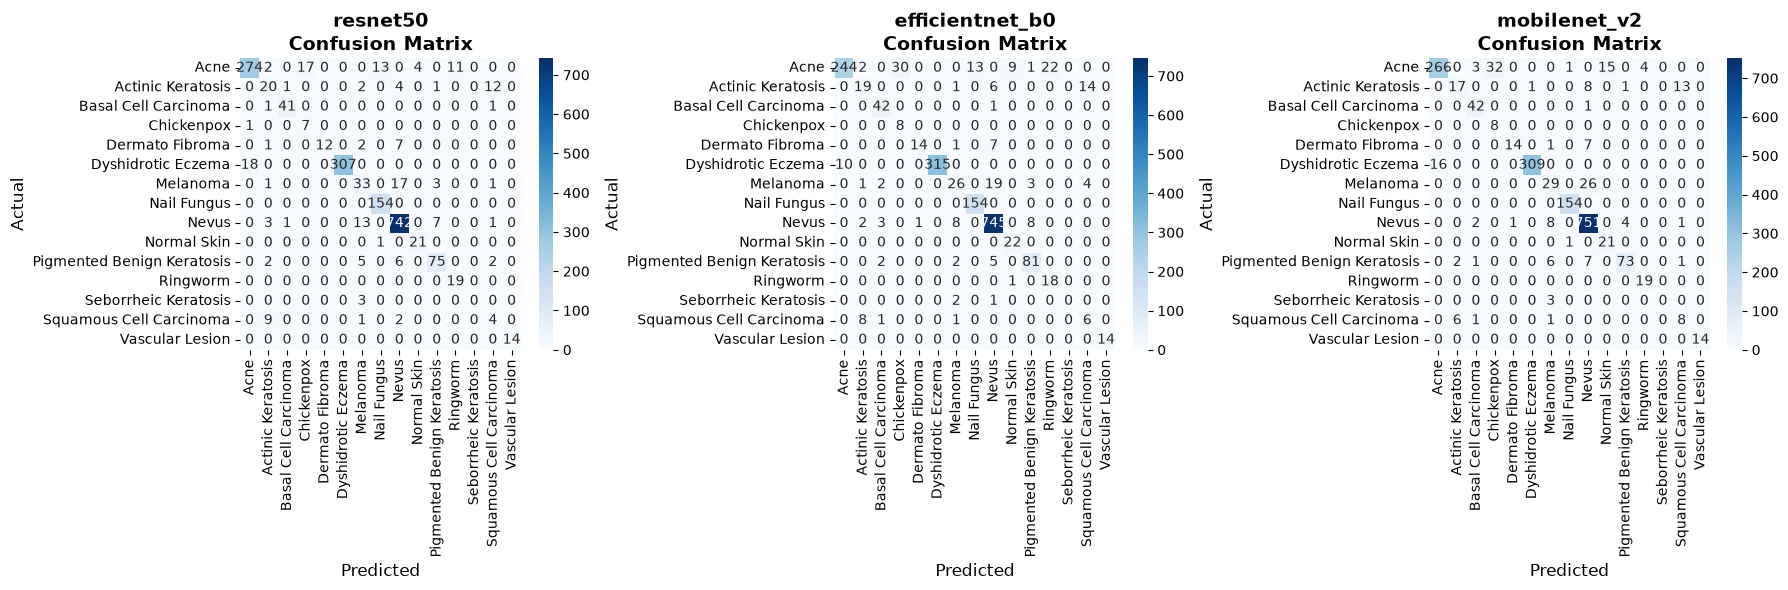

In [14]:
# ============================================================
# CONFUSION MATRICES — ALL TRAINED MODELS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn

from sklearn.metrics import confusion_matrix


# ------------------------------------------------------------
# Models to evaluate
# ------------------------------------------------------------

model_names = list(trained_models.keys())

print("Models available:")
print(model_names)


# ------------------------------------------------------------
# Create subplots
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    len(model_names),
    figsize=(6 * len(model_names), 6)
)

# If only one model exists
if len(model_names) == 1:
    axes = [axes]


# ------------------------------------------------------------
# Generate confusion matrix for each model
# ------------------------------------------------------------

for ax, arch in zip(axes, model_names):

    print(f"Generating confusion matrix for: {arch}")

    # Evaluate model
    _, _, preds, labels = evaluate(
        trained_models[arch],
        val_loader,
        nn.CrossEntropyLoss()
    )

    # Convert PyTorch tensors to NumPy
    if torch.is_tensor(preds):
        preds = preds.detach().cpu().numpy()

    if torch.is_tensor(labels):
        labels = labels.detach().cpu().numpy()

    # Make sure arrays are 1-D
    preds = np.asarray(preds).flatten()
    labels = np.asarray(labels).flatten()

    # --------------------------------------------------------
    # Confusion matrix
    # --------------------------------------------------------

    cm = confusion_matrix(labels, preds)

    # --------------------------------------------------------
    # Class labels
    # --------------------------------------------------------

    if "classes" in globals():
        display_classes = classes
    else:
        display_classes = [str(i) for i in range(cm.shape[0])]

    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=display_classes,
        yticklabels=display_classes,
        cbar=True
    )

    ax.set_title(
        f"{arch}\nConfusion Matrix",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)

    ax.tick_params(
        axis="x",
        rotation=90
    )

    ax.tick_params(
        axis="y",
        rotation=0
    )


# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

plt.tight_layout()
plt.show()

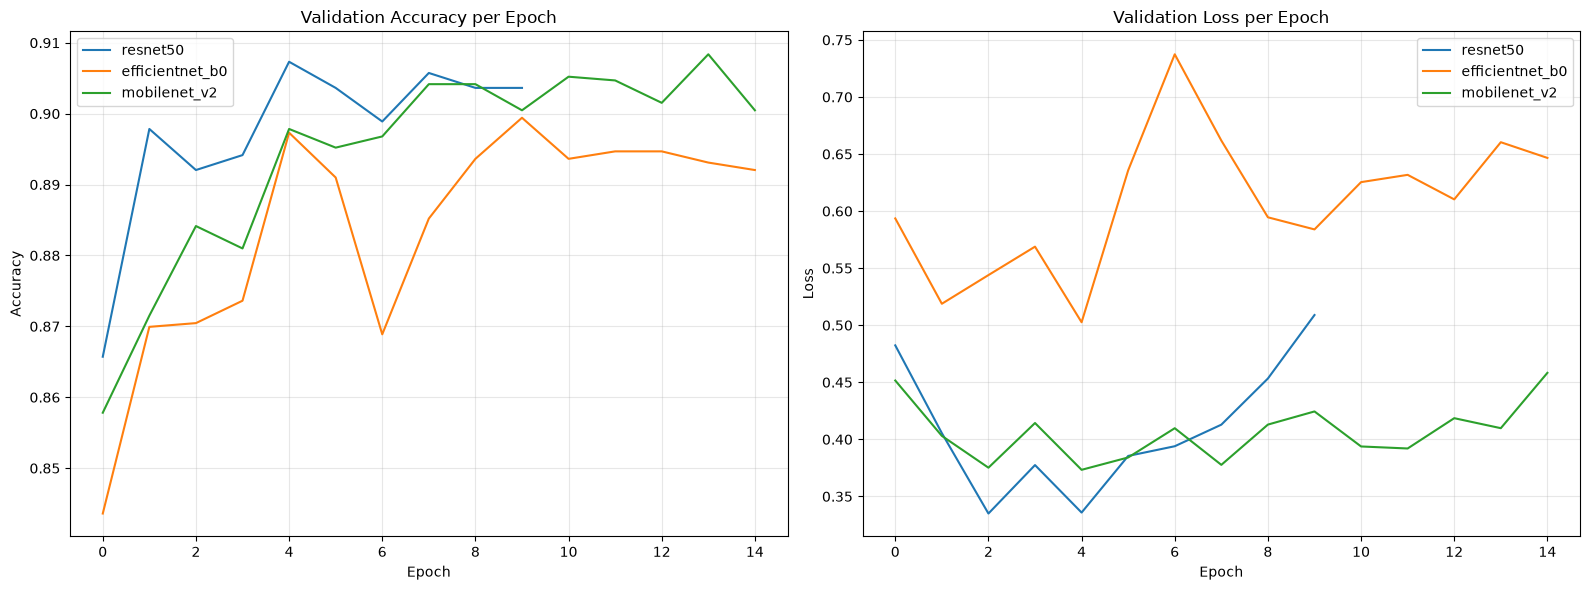

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for arch in ARCHITECTURES:
    axes[0].plot(training_histories[arch]["val_acc"], label=arch)
    axes[1].plot(training_histories[arch]["val_loss"], label=arch)

axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Compare against the YOLO26s-cls baseline (optional)
If your earlier `baseline_224/weights/best.pt` is still around, it's added to the chart. Otherwise only the three transfer-learning models are compared.

Baseline weights not found — comparing the three transfer-learning models only.


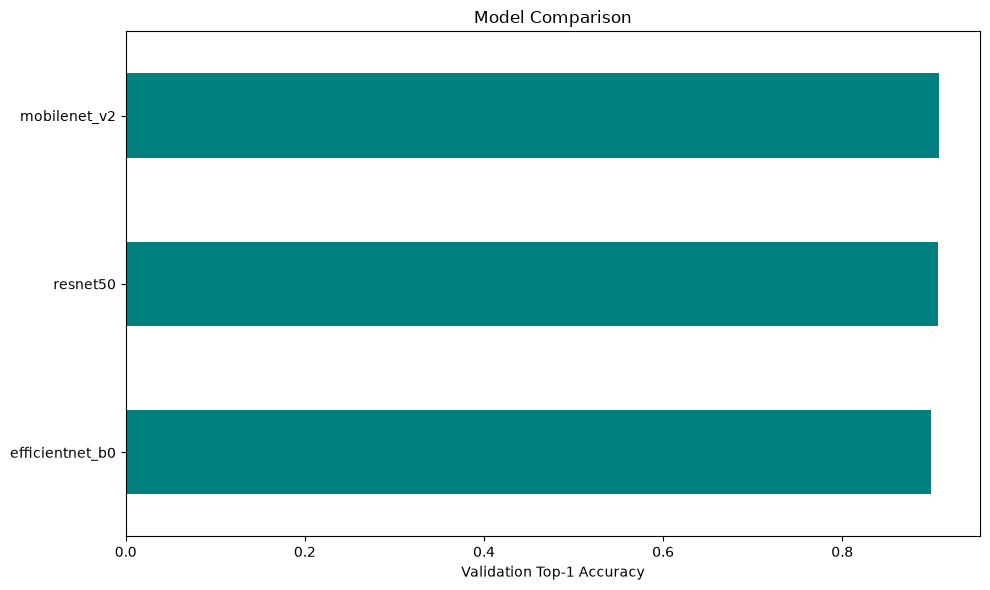

,val_accuracy
efficientnet_b0,0.899421
resnet50,0.907320
mobilenet_v2,0.908373


In [ ]:
comparison = {arch: res["accuracy"] for arch, res in detailed_results.items()}

if BASELINE_PATH.exists():
    baseline_model = YOLO(str(BASELINE_PATH))
    baseline_metrics = baseline_model.val(data=str(WORK_DIR), imgsz=224)
    comparison["yolo26s_cls_baseline"] = float(baseline_metrics.top1)
else:
    print("Baseline weights not found — comparing the three transfer-learning models only.")

comp_series = pd.Series(comparison).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
comp_series.plot(kind="barh", color="teal")
plt.xlabel("Validation Top-1 Accuracy")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

display(comp_series.to_frame("val_accuracy"))

## Part 2 — YOLO detection: localize pigmentation patches, acne, dark spots, moles
No bounding-box labels exist in the source dataset, so we first generate
**pseudo bounding boxes** with classical image processing (LAB color space +
Otsu thresholding + contours), build a proper YOLO-detection folder structure
from them, then fine-tune a YOLO detection model.

In [54]:

# ============================================================
# DATASET AUDIT — SAFE, NO FILES DELETED
# ============================================================

from pathlib import Path
from collections import defaultdict
import hashlib
import csv
import cv2
import numpy as np

SOURCE_DIR = Path(r"D:\nn\skin_yolo_dataset\train")
REPORT_PATH = Path(r"D:\nn\skin_yolo_dataset_audit.csv")

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not SOURCE_DIR.is_dir():
    raise FileNotFoundError(f"Dataset not found: {SOURCE_DIR}")

records = []
hash_to_paths = defaultdict(list)

for path in SOURCE_DIR.rglob("*"):
    if not path.is_file() or path.suffix.lower() not in EXTENSIONS:
        continue

    row = {
        "path": str(path),
        "class_folder": path.relative_to(SOURCE_DIR).parts[0],
        "width": "",
        "height": "",
        "mean_brightness": "",
        "dark_pixel_percent": "",
        "border_dark_percent": "",
        "sha256": "",
        "issues": ""
    }

    try:
        # Hash file contents to find exact duplicates.
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        row["sha256"] = digest
        hash_to_paths[digest].append(str(path))

        image = cv2.imread(str(path))

        if image is None:
            row["issues"] = "Unreadable image"
            records.append(row)
            continue

        h, w = image.shape[:2]
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        row["width"] = w
        row["height"] = h
        row["mean_brightness"] = round(float(gray.mean()), 2)
        row["dark_pixel_percent"] = round(
            float(np.mean(gray < 15) * 100), 2
        )

        border = max(2, int(min(h, w) * 0.05))
        border_pixels = np.concatenate([
            gray[:border, :].ravel(),
            gray[-border:, :].ravel(),
            gray[:, :border].ravel(),
            gray[:, -border:].ravel()
        ])

        row["border_dark_percent"] = round(
            float(np.mean(border_pixels < 15) * 100), 2
        )

        issues = []

        if min(h, w) < 64:
            issues.append("Very small image")

        if np.mean(gray < 15) > 0.25:
            issues.append("Review: large dark area")

        if np.mean(border_pixels < 15) > 0.40:
            issues.append("Review: dark borders")

        row["issues"] = "; ".join(issues)

    except Exception as exc:
        row["issues"] = f"Read error: {exc}"

    records.append(row)

# Flag exact duplicates.
for row in records:
    if row["sha256"] and len(hash_to_paths[row["sha256"]]) > 1:
        duplicate_note = "Exact duplicate"
        row["issues"] = "; ".join(
            part for part in [row["issues"], duplicate_note] if part
        )

if not records:
    raise RuntimeError("No image files were found.")

with REPORT_PATH.open("w", newline="", encoding="utf-8-sig") as f:
    writer = csv.DictWriter(f, fieldnames=records[0].keys())
    writer.writeheader()
    writer.writerows(records)

print("=" * 60)
print("DATASET AUDIT COMPLETED")
print("=" * 60)
print("Images scanned:", len(records))
print("Exact duplicate groups:", sum(
    1 for paths in hash_to_paths.values() if len(paths) > 1
))
print("Report saved:", REPORT_PATH)
print("\nReview the CSV and inspect flagged images manually.")


DATASET AUDIT COMPLETED
Images scanned: 46334
Exact duplicate groups: 152
Report saved: D:\nn\skin_yolo_dataset_audit.csv

Review the CSV and inspect flagged images manually.


In [51]:

# ============================================================
# IMPROVED PSEUDO BOUNDING BOX GENERATOR
# Dark spots + local redness contrast
# ============================================================

import cv2
import numpy as np

def generate_pseudo_bboxes(
    image_path,
    min_area_ratio=0.00015,
    max_area_ratio=0.04,
    max_boxes=5,
    min_thr=8,
    exclude_border=2
):
    """
    Generate candidate bounding boxes around locally darker
    or redder regions.

    Returns:
        List of (x, y, width, height) in pixel coordinates.

    NOTE:
        These are heuristic proposals, not verified acne labels.
    """

    img = cv2.imread(str(image_path))

    if img is None:
        return []

    h, w = img.shape[:2]

    if h < 16 or w < 16:
        return []

    # --------------------------------------------------------
    # 1. Convert image to LAB colour space
    # --------------------------------------------------------

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    lightness = lab[:, :, 0]
    redness = lab[:, :, 1]

    light_smooth = cv2.GaussianBlur(
        lightness, (5, 5), 0
    )

    red_smooth = cv2.GaussianBlur(
        redness, (5, 5), 0
    )

    sigma = max(3.0, min(h, w) / 10.0)

    light_bg = cv2.GaussianBlur(
        light_smooth, (0, 0), sigmaX=sigma
    )

    red_bg = cv2.GaussianBlur(
        red_smooth, (0, 0), sigmaX=sigma
    )

    # --------------------------------------------------------
    # 2. Calculate local darkness and redness contrast
    # --------------------------------------------------------

    dark_diff = np.clip(
        light_bg.astype(np.float32)
        - light_smooth.astype(np.float32),
        0, 255
    ).astype(np.uint8)

    red_diff = np.clip(
        red_smooth.astype(np.float32)
        - red_bg.astype(np.float32),
        0, 255
    ).astype(np.uint8)

    dark_thr, _ = cv2.threshold(
        dark_diff,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    red_thr, _ = cv2.threshold(
        red_diff,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    dark_thr = max(float(min_thr), float(dark_thr))
    red_thr = max(float(min_thr), float(red_thr))

    dark_mask = (
        dark_diff > dark_thr
    ).astype(np.uint8) * 255

    red_mask = (
        red_diff > red_thr
    ).astype(np.uint8) * 255

    # Combine candidate regions
    mask = cv2.bitwise_or(dark_mask, red_mask)

    # --------------------------------------------------------
    # 3. Remove very dark empty regions
    # --------------------------------------------------------

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    value = hsv[:, :, 2]

    valid_region = (value > 25).astype(np.uint8) * 255

    mask = cv2.bitwise_and(mask, valid_region)

    # Exclude image-border artifacts
    b = max(0, int(exclude_border))

    if b > 0 and h > 2 * b and w > 2 * b:
        mask[:b, :] = 0
        mask[-b:, :] = 0
        mask[:, :b] = 0
        mask[:, -b:] = 0

    # --------------------------------------------------------
    # 4. Morphological cleanup
    # --------------------------------------------------------

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (3, 3)
    )

    mask = cv2.morphologyEx(
        mask, cv2.MORPH_OPEN, kernel
    )

    mask = cv2.morphologyEx(
        mask, cv2.MORPH_CLOSE, kernel
    )

    # --------------------------------------------------------
    # 5. Connected components
    # --------------------------------------------------------

    count, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            mask,
            connectivity=8
        )
    )

    min_area = max(
        5,
        int(min_area_ratio * h * w)
    )

    max_area = max(
        min_area,
        int(max_area_ratio * h * w)
    )

    candidates = []

    for i in range(1, count):

        x, y, bw, bh, area = stats[i]

        # Reject tiny noise and large regions
        if area < min_area or area > max_area:
            continue

        # Reject oversized regions
        if bw > 0.25 * w or bh > 0.25 * h:
            continue

        # Reject extreme aspect ratios
        aspect_ratio = bw / max(bh, 1)

        if not 0.20 <= aspect_ratio <= 5.0:
            continue

        # Add a small margin around each region
        pad = 2

        x1 = max(0, int(x) - pad)
        y1 = max(0, int(y) - pad)
        x2 = min(w, int(x + bw) + pad)
        y2 = min(h, int(y + bh) + pad)

        box_area = (x2 - x1) * (y2 - y1)

        component_mask = labels == i

        contrast = float(
            np.mean(dark_diff[component_mask])
            + np.mean(red_diff[component_mask])
        )

        candidates.append({
            "box": (
                x1,
                y1,
                x2 - x1,
                y2 - y1
            ),
            "box_area": box_area,
            "contrast": contrast
        })

    # Prefer higher-contrast candidates.
    # Smaller boxes break ties.
    candidates.sort(
        key=lambda item: (
            item["contrast"],
            -item["box_area"]
        ),
        reverse=True
    )

    return [
        item["box"]
        for item in candidates[:max_boxes]
    ]


# ============================================================
# QUICK TEST
# ============================================================

from pathlib import Path

TEST_DIR = Path(r"D:\nn\skin_yolo_dataset\train")

test_images = [
    p for p in TEST_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {
        ".jpg", ".jpeg", ".png", ".bmp", ".webp"
    }
]

if not test_images:
    print("No test images found.")
else:
    test_image = test_images[0]
    test_boxes = generate_pseudo_bboxes(test_image)

    print("Test image:", test_image.name)
    print("Image path:", test_image)
    print("Number of candidate boxes:", len(test_boxes))
    print("Boxes (x, y, width, height):")

    for box in test_boxes:
        print(box)


Test image: 07Acne081101.jpg
Image path: D:\nn\skin_yolo_dataset\train\Acne\07Acne081101.jpg
Number of candidate boxes: 5
Boxes (x, y, width, height):
(168, 209, 19, 21)
(361, 166, 29, 29)
(428, 152, 35, 57)
(181, 158, 29, 34)
(384, 230, 28, 38)


15-CLASS PSEUDO-BOX INSPECTION
Classes found: 1
Images found: 46334
Images selected: 2
Uncategorized: 46334 images
Uncategorized/Squamous Cell Carcinoma__ISIC_0029462_0_8941.jpeg: 5 candidates
Uncategorized/Basal Cell Carcinoma___182_2081384.jpg: 5 candidates


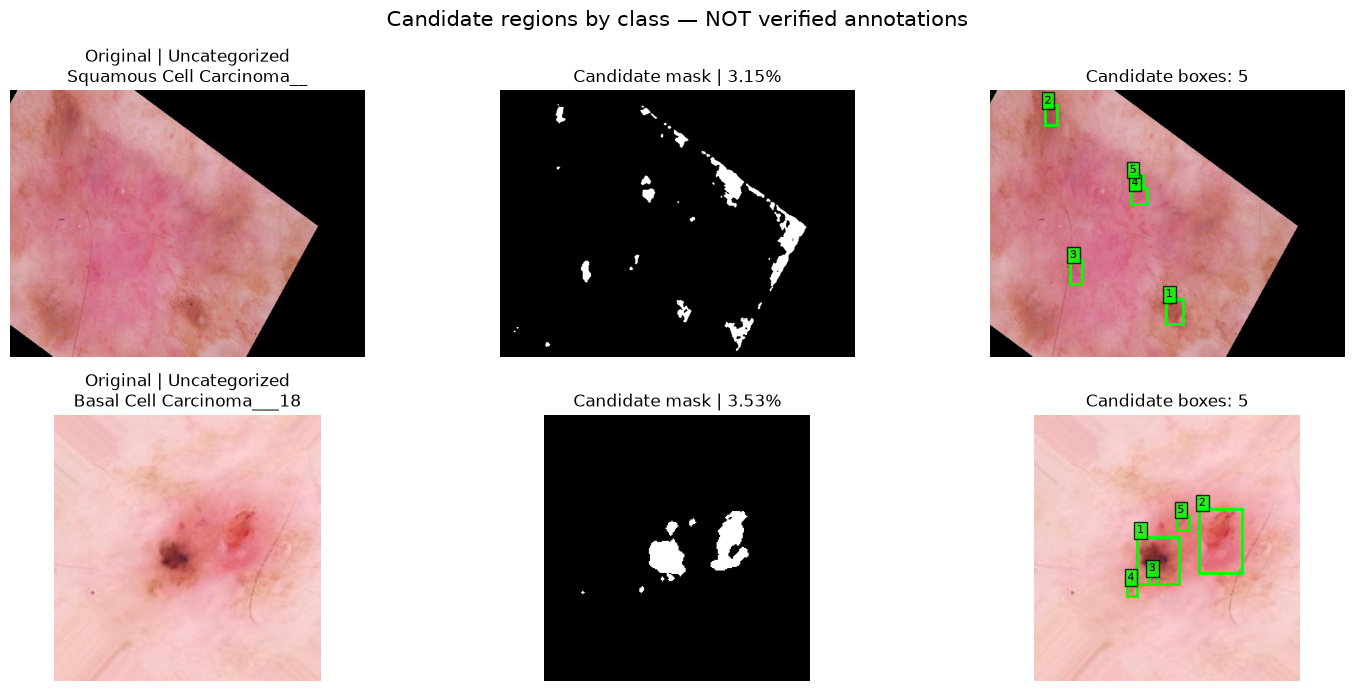


Inspection completed.
Do not use these candidate boxes as verified YOLO labels.


In [55]:

# ============================================================
# PSEUDO-BOX SANITY CHECK — 15-CLASS DATASET
# Original | Candidate mask | Candidate bounding boxes
# Inspection only: does NOT create YOLO training labels
# ============================================================

from pathlib import Path
from collections import defaultdict
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# ============================================================
# 1. CONFIGURATION
# ============================================================

WORK_DIR = Path(r"D:\nn\skin_yolo_detect")
TRAIN_DIR = WORK_DIR / "images" / "train"

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
NUM_PER_CLASS = 2
SEED = 42

MIN_AREA_RATIO = 0.00015
MAX_AREA_RATIO = 0.04
MAX_BOXES = 5
MIN_THRESHOLD = 8
EXCLUDE_BORDER_RATIO = 0.02

if not TRAIN_DIR.is_dir():
    raise FileNotFoundError(
        f"Image directory not found: {TRAIN_DIR}\n"
        "Check your dataset structure before continuing."
    )

# ============================================================
# 2. FIND IMAGES BY CLASS FOLDER
# ============================================================

class_images = defaultdict(list)

for path in TRAIN_DIR.rglob("*"):
    if not path.is_file() or path.suffix.lower() not in EXTENSIONS:
        continue

    relative = path.relative_to(TRAIN_DIR)

    # Assumes images are organized as images/train/ClassName/image.jpg
    if len(relative.parts) >= 2:
        class_name = relative.parts[0]
    else:
        class_name = "Uncategorized"

    class_images[class_name].append(path)

if not class_images:
    raise FileNotFoundError(f"No images found in {TRAIN_DIR}")

rng = random.Random(SEED)
samples = []

for class_name in sorted(class_images):
    paths = class_images[class_name]
    selected = rng.sample(paths, min(NUM_PER_CLASS, len(paths)))
    samples.extend((class_name, path) for path in selected)

print("=" * 65)
print("15-CLASS PSEUDO-BOX INSPECTION")
print("=" * 65)
print("Classes found:", len(class_images))
print("Images found:", sum(map(len, class_images.values())))
print("Images selected:", len(samples))

for class_name, paths in sorted(class_images.items()):
    print(f"{class_name}: {len(paths)} images")

# ============================================================
# 3. GENERATE CANDIDATE MASKS AND BOXES
# ============================================================

def generate_candidates(image):
    if image is None or image.ndim != 3:
        return None, []

    h, w = image.shape[:2]

    if h < 16 or w < 16:
        return np.zeros((h, w), dtype=np.uint8), []

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    light = lab[:, :, 0]
    red = lab[:, :, 1]

    light_smooth = cv2.GaussianBlur(light, (5, 5), 0)
    red_smooth = cv2.GaussianBlur(red, (5, 5), 0)

    sigma = max(3.0, min(h, w) / 10.0)

    light_bg = cv2.GaussianBlur(
        light_smooth, (0, 0), sigmaX=sigma
    )
    red_bg = cv2.GaussianBlur(
        red_smooth, (0, 0), sigmaX=sigma
    )

    dark_diff = np.clip(
        light_bg.astype(np.float32)
        - light_smooth.astype(np.float32),
        0, 255
    ).astype(np.uint8)

    red_diff = np.clip(
        red_smooth.astype(np.float32)
        - red_bg.astype(np.float32),
        0, 255
    ).astype(np.uint8)

    dark_thr, _ = cv2.threshold(
        dark_diff, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    red_thr, _ = cv2.threshold(
        red_diff, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    dark_mask = (
        dark_diff > max(MIN_THRESHOLD, float(dark_thr))
    ).astype(np.uint8) * 255

    red_mask = (
        red_diff > max(MIN_THRESHOLD, float(red_thr))
    ).astype(np.uint8) * 255

    mask = cv2.bitwise_or(dark_mask, red_mask)

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    mask[hsv[:, :, 2] <= 25] = 0

    border = max(1, int(min(h, w) * EXCLUDE_BORDER_RATIO))
    mask[:border, :] = 0
    mask[-border:, :] = 0
    mask[:, :border] = 0
    mask[:, -border:] = 0

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (3, 3)
    )
    mask = cv2.morphologyEx(
        mask, cv2.MORPH_OPEN, kernel
    )

    count, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask, connectivity=8
    )

    min_area = max(5, int(MIN_AREA_RATIO * h * w))
    max_area = max(min_area, int(MAX_AREA_RATIO * h * w))

    candidates = []

    for i in range(1, count):
        x, y, bw, bh, area = stats[i]

        if area < min_area or area > max_area:
            continue

        if bw > 0.25 * w or bh > 0.25 * h:
            continue

        aspect = bw / max(bh, 1)
        if not 0.20 <= aspect <= 5.0:
            continue

        pad = 2
        x1 = max(0, int(x) - pad)
        y1 = max(0, int(y) - pad)
        x2 = min(w, int(x + bw) + pad)
        y2 = min(h, int(y + bh) + pad)

        if x2 <= x1 or y2 <= y1:
            continue

        component = labels == i

        contrast = float(
            np.mean(dark_diff[component])
            + np.mean(red_diff[component])
        )

        candidates.append({
            "box": (x1, y1, x2 - x1, y2 - y1),
            "box_area": (x2 - x1) * (y2 - y1),
            "contrast": contrast
        })

    candidates.sort(
        key=lambda item: (item["contrast"], -item["box_area"]),
        reverse=True
    )

    return mask, [
        item["box"] for item in candidates[:MAX_BOXES]
    ]

# ============================================================
# 4. VISUALIZE SAMPLES
# ============================================================

ncols = 3
nrows = len(samples)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, max(4, 3.5 * nrows)),
    squeeze=False
)

for row, (class_name, path) in enumerate(samples):
    image = cv2.imread(str(path))

    if image is None:
        print("[WARNING] Unreadable:", path)
        for ax in axes[row]:
            ax.axis("off")
        continue

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask, boxes = generate_candidates(image)

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(
        f"Original | {class_name}\n{path.name[:25]}"
    )

    axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=255)
    axes[row, 1].set_title(
        f"Candidate mask | {(mask > 0).mean() * 100:.2f}%"
    )

    axes[row, 2].imshow(rgb)

    for idx, (x, y, bw, bh) in enumerate(boxes, start=1):
        axes[row, 2].add_patch(
            plt.Rectangle(
                (x, y), bw, bh,
                linewidth=2,
                edgecolor="lime",
                facecolor="none"
            )
        )

        axes[row, 2].text(
            x, max(0, y - 3), str(idx),
            color="black",
            fontsize=8,
            bbox=dict(facecolor="lime", alpha=0.8, pad=2)
        )

    axes[row, 2].set_title(f"Candidate boxes: {len(boxes)}")

    for ax in axes[row]:
        ax.axis("off")

    print(
        f"{class_name}/{path.name}: "
        f"{len(boxes)} candidates"
    )

fig.suptitle(
    "Candidate regions by class — NOT verified annotations",
    fontsize=15
)
plt.tight_layout()
plt.show()

print("\nInspection completed.")
print("Do not use these candidate boxes as verified YOLO labels.")


In [ ]:
DETECT_DIR = Path(str(BASE_DIR / "skin_yolo_detect"))

if DETECT_DIR.exists():
    shutil.rmtree(DETECT_DIR)

for split in ["train", "val"]:
    (DETECT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DETECT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

class_to_id = {c: i for i, c in enumerate(classes)}

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def build_detection_split(split_name):
    src_root = WORK_DIR / split_name
    count = 0
    fallback_count = 0   # images where no dark region was found

    for cls_dir in sorted(src_root.iterdir()):
        if not cls_dir.is_dir():
            continue
        if cls_dir.name not in class_to_id:
            print(f"Skipping unknown class folder: {cls_dir.name}")
            continue
        cls_id = class_to_id[cls_dir.name]

        # only real image files (skips Thumbs.db, .csv, etc.)
        img_paths = sorted(
            p for p in cls_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXT
        )

        for img_path in img_paths:
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            h, w = img.shape[:2]

            boxes = generate_pseudo_bboxes(img_path)
            if not boxes:
                # fallback: a centered box covering most of the image
                boxes = [(int(0.1 * w), int(0.1 * h), int(0.8 * w), int(0.8 * h))]
                fallback_count += 1

            # include the extension so "a.jpg" and "a.png" never collide
            uid = f"{cls_dir.name}__{img_path.stem}_{img_path.suffix.lower().lstrip('.')}"
            dst_img = DETECT_DIR / "images" / split_name / f"{uid}{img_path.suffix.lower()}"
            shutil.copy(img_path, dst_img)

            label_lines = []
            for (x, y, bw, bh) in boxes:
                x_center = (x + bw / 2) / w
                y_center = (y + bh / 2) / h
                norm_w = bw / w
                norm_h = bh / h
                label_lines.append(
                    f"{cls_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"
                )

            label_path = DETECT_DIR / "labels" / split_name / (uid + ".txt")
            label_path.write_text("\n".join(label_lines))
            count += 1

    print(f"{split_name}: {count} images labelled "
          f"({fallback_count} used the centered fallback box)")


build_detection_split("train")
build_detection_split("val")

train: 46334 images labelled
val: 1899 images labelled


In [56]:
yaml_lines = [f"path: {DETECT_DIR.as_posix()}", "train: images/train", "val: images/val", "", "names:"]
for i, c in enumerate(classes):
    yaml_lines.append(f"  {i}: {c}")

yaml_content = "\n".join(yaml_lines) + "\n"

yaml_path = DETECT_DIR / "data.yaml"
yaml_path.write_text(yaml_content)

print(yaml_content)

path: D:/nn/skin_yolo_detect
train: images/train
val: images/val

names:
  0: Acne
  1: Actinic Keratosis
  2: Basal Cell Carcinoma
  3: Chickenpox
  4: Dermato Fibroma
  5: Dyshidrotic Eczema
  6: Melanoma
  7: Nail Fungus
  8: Nevus
  9: Normal Skin
  10: Pigmented Benign Keratosis
  11: Ringworm
  12: Seborrheic Keratosis
  13: Squamous Cell Carcinoma
  14: Vascular Lesion



In [57]:
# ============================================================
# YOLO DETECTION TRAINING
# ============================================================

import torch
from pathlib import Path
from ultralytics import YOLO

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

YOLO_MODEL = "yolo26n.pt"      # Nano model
YOLO_FALLBACK_MODEL = "yolo11n.pt"   # used if your ultralytics build lacks yolo26
YOLO_EPOCHS = 30
YOLO_IMGSZ = 416               # must be a multiple of 32

# Batch size: reuse the VRAM-based value, but cap it because 416px
# needs more memory per image than the 224px classifiers did
YOLO_BATCH = min(globals().get("YOLO_BATCH", 16), 32)

YOLO_DEVICE = globals().get(
    "YOLO_DEVICE",
    0 if torch.cuda.is_available() else "cpu"
)

NUM_WORKERS = globals().get("NUM_WORKERS", 2)

USE_AMP = globals().get("USE_AMP", torch.cuda.is_available())

SEED = globals().get("SEED", 42)

# ------------------------------------------------------------
# Pre-flight checks (clear errors instead of cryptic YOLO ones)
# ------------------------------------------------------------

assert Path(yaml_path).exists(), f"data.yaml not found: {yaml_path} - run the YAML cell first."

n_train = len(list((DETECT_DIR / "images" / "train").glob("*")))
n_val = len(list((DETECT_DIR / "images" / "val").glob("*")))
assert n_train > 0, "No training images in skin_yolo_detect - re-run the detection builder cell."
assert n_val > 0, "No validation images in skin_yolo_detect - check the Step 0 split."

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("=" * 70)
print("YOLO TRAINING CONFIGURATION")
print("=" * 70)

print(f"Model       : {YOLO_MODEL}")
print(f"Epochs      : {YOLO_EPOCHS}")
print(f"Image Size  : {YOLO_IMGSZ}")
print(f"Batch Size  : {YOLO_BATCH}")
print(f"Device      : {YOLO_DEVICE}")
print(f"Workers     : {NUM_WORKERS}")
print(f"AMP         : {USE_AMP}")
print(f"Train / Val : {n_train} / {n_val} images")
print(f"Dataset YAML: {yaml_path}")
print("=" * 70)

# ------------------------------------------------------------
# Load YOLO model (with fallback)
# ------------------------------------------------------------

try:
    detect_model = YOLO(YOLO_MODEL)
except Exception as e:
    print(f"Could not load {YOLO_MODEL} ({e}).\nFalling back to {YOLO_FALLBACK_MODEL}")
    YOLO_MODEL = YOLO_FALLBACK_MODEL
    detect_model = YOLO(YOLO_MODEL)

# ------------------------------------------------------------
# Train YOLO
# ------------------------------------------------------------

try:
    detect_results = detect_model.train(
        data=str(yaml_path),

        epochs=YOLO_EPOCHS,
        imgsz=YOLO_IMGSZ,
        batch=YOLO_BATCH,

        optimizer="AdamW",
        lr0=0.001,
        weight_decay=0.0005,

        patience=10,
        seed=SEED,

        device=YOLO_DEVICE,
        workers=NUM_WORKERS,
        amp=USE_AMP,

        exist_ok=True,

        project=str(BASE_DIR / "yolo_runs"),
        name="detection_pigmentation",

        verbose=True
    )

except RuntimeError as e:
    if "out of memory" in str(e).lower():
        raise RuntimeError(
            f"CUDA out of memory at batch={YOLO_BATCH}, imgsz={YOLO_IMGSZ}. "
            "Set YOLO_BATCH to 8 (or YOLO_IMGSZ to 320), then re-run this cell."
        ) from e
    raise

print("\n" + "=" * 70)
print("✅ YOLO TRAINING COMPLETED")
print("Best weights:", Path(detect_model.trainer.best))
print("=" * 70)

YOLO TRAINING CONFIGURATION
Model       : yolo26n.pt
Epochs      : 30
Image Size  : 416
Batch Size  : 32
Device      : 0
Workers     : 0
AMP         : True
Train / Val : 46334 / 1899 images
Dataset YAML: D:\nn\skin_yolo_detect\data.yaml
Ultralytics 8.4.174  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\nn\skin_yolo_detect\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, 

In [58]:
DETECT_RUN_DIR = Path(str(BASE_DIR / "yolo_runs/detection_pigmentation"))
best_detect_path = DETECT_RUN_DIR / "weights" / "best.pt"

best_detect_model = YOLO(str(best_detect_path))
detect_metrics = best_detect_model.val(data=str(yaml_path))

print("mAP50:", detect_metrics.box.map50)
print("mAP50-95:", detect_metrics.box.map)

Ultralytics 8.4.174  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO26n summary (fused): 120 layers, 2,377,761 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 898.9802.0 MB/s, size: 170.6 KB)
val: Scanning D:\nn\skin_yolo_detect\labels\val.cache... 1899 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1899/1899  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 119/119 2.3s/it 4:390.2s:34
                   all       1899       4418       0.53      0.625      0.596      0.481
                  Acne        321        881      0.643      0.425      0.522      0.399
     Actinic Keratosis         40        131      0.446      0.344      0.364      0.269
  Basal Cell Carcinoma         43        141      0.657      0.723       0.76      0.587
            Chickenpox          8         29     0.0835      0.966      0.382      0.337
       Dermato

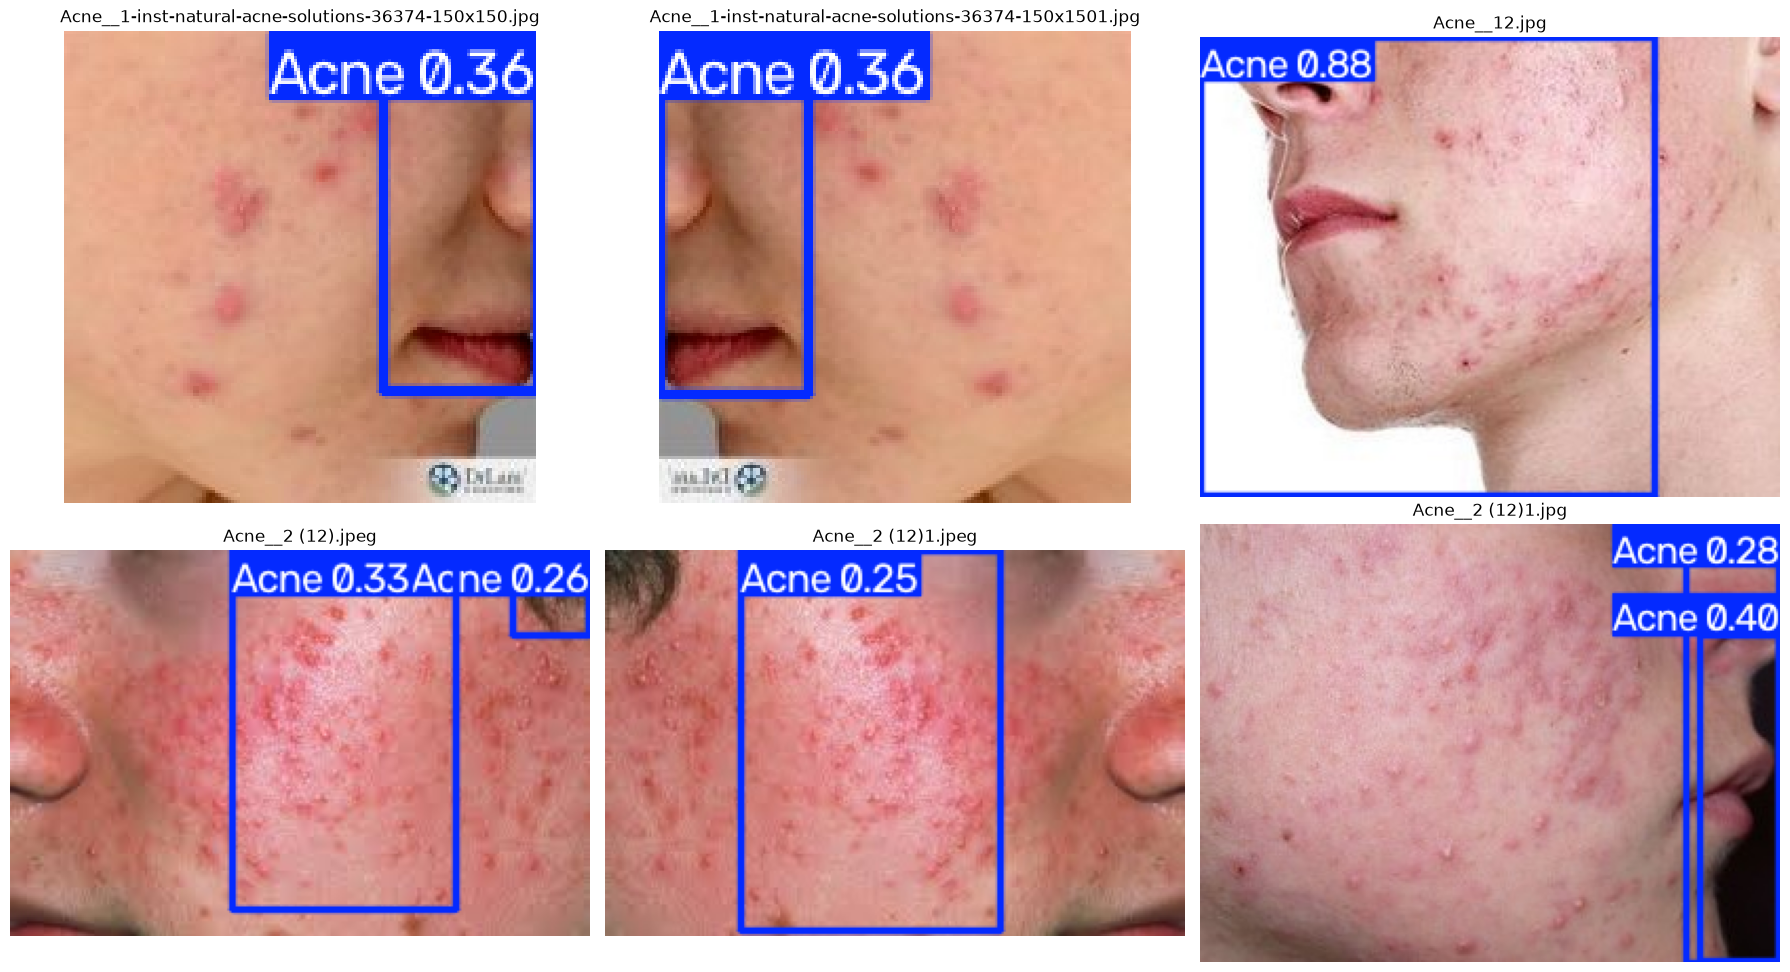

In [59]:
val_sample_images = list((DETECT_DIR / "images" / "val").glob("*"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, val_sample_images):
    result = best_detect_model.predict(str(img_path), imgsz=224, conf=0.25, verbose=False)[0]
    plotted = result.plot()
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Part 3 — U-Net segmentation: pigmented-region mask + percentage
Same weak-supervision idea as Part 2, but this time we generate a full binary
**mask** (not just a box) and train a U-Net from scratch to predict it. Once
trained, the model gives you, for any image, the **percentage of the skin
area that is pigmented** — the exact deliverable your module table asks for.

In [ ]:
def generate_pseudo_mask(image_path, img_size=256, min_thr=12):
    """
    Weak-supervision helper: returns (resized BGR image, binary mask) where the
    mask marks regions DARKER than the surrounding skin tone.
    Returns (None, None) if the image cannot be read.
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return None, None

    img = cv2.resize(img, (img_size, img_size))

    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel = lab[:, :, 0]

    # Smooth lightly to remove noise
    b = cv2.GaussianBlur(l_channel, (7, 7), 0)

    # Local skin-tone baseline (heavy blur): lighting gradients cancel out
    bg = cv2.GaussianBlur(l_channel, (0, 0), sigmaX=img_size / 8)

    # Only pixels DARKER than their surroundings count (glare is ignored)
    diff = np.clip(bg.astype(np.float32) - b.astype(np.float32), 0, 255).astype(np.uint8)

    thr, mask = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Uniform skin -> empty mask instead of segmenting noise
    if thr < min_thr:
        return img, np.zeros((img_size, img_size), dtype=np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))

    return img, (mask > 0).astype(np.uint8)

In [ ]:
SEG_DIR = Path(str(BASE_DIR / "skin_seg_dataset"))

if SEG_DIR.exists():
    shutil.rmtree(SEG_DIR)

for split in ["train", "val"]:
    (SEG_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (SEG_DIR / "masks" / split).mkdir(parents=True, exist_ok=True)

IMG_SIZE_SEG = 256
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}


def build_segmentation_split(split_name, max_per_class=None, seed=42):
    src_root = WORK_DIR / split_name
    count = 0
    empty_masks = 0
    rng = random.Random(seed)

    for cls_dir in sorted(src_root.iterdir()):
        if not cls_dir.is_dir():
            continue

        # only real image files (skips Thumbs.db, .csv, etc.)
        img_paths = sorted(
            p for p in cls_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMG_EXT
        )

        # random (but repeatable) subset, so the cap doesn't just keep
        # the first files alphabetically
        if max_per_class and len(img_paths) > max_per_class:
            img_paths = rng.sample(img_paths, max_per_class)

        for img_path in img_paths:
            img, mask = generate_pseudo_mask(img_path, IMG_SIZE_SEG)
            if img is None:          # unreadable file
                continue

            # include the extension so "a.jpg" and "a.png" never collide
            uid = f"{cls_dir.name}__{img_path.stem}_{img_path.suffix.lower().lstrip('.')}"
            out_img = SEG_DIR / "images" / split_name / (uid + ".png")
            out_mask = SEG_DIR / "masks" / split_name / (uid + ".png")

            cv2.imwrite(str(out_img), img)
            cv2.imwrite(str(out_mask), mask * 255)

            if mask.sum() == 0:
                empty_masks += 1
            count += 1

    print(f"{split_name}: {count} image/mask pairs created "
          f"({empty_masks} with an empty mask = no dark region found)")


# Capped per class to keep training time reasonable on a laptop GPU — raise these
# (or set to None for "all images") if you have time/compute to spare.
build_segmentation_split("train", max_per_class=150)
build_segmentation_split("val", max_per_class=40)

train: 2250 image/mask pairs created
val: 424 image/mask pairs created


In [31]:
class SkinSegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_size=256, augment=False):
        self.img_paths = sorted(Path(img_dir).glob("*.png"))
        self.mask_dir = Path(mask_dir)
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self.mask_dir / img_path.name

        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        if self.augment and random.random() > 0.5:
            img = cv2.flip(img, 1)
            mask = cv2.flip(mask, 1)

        img = img.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)

        return img_tensor, mask_tensor


seg_train_dataset = SkinSegmentationDataset(
    SEG_DIR / "images" / "train", SEG_DIR / "masks" / "train", augment=True
)
seg_val_dataset = SkinSegmentationDataset(
    SEG_DIR / "images" / "val", SEG_DIR / "masks" / "val", augment=False
)

seg_loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=NUM_WORKERS > 0)
seg_train_loader = DataLoader(seg_train_dataset, batch_size=SEG_BATCH, shuffle=True, **seg_loader_kwargs)
seg_val_loader = DataLoader(seg_val_dataset, batch_size=SEG_BATCH, shuffle=False, **seg_loader_kwargs)

print("Seg train samples:", len(seg_train_dataset))
print("Seg val samples:", len(seg_val_dataset))

Seg train samples: 2248
Seg val samples: 422


In [32]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_features=32):
        super().__init__()
        f = base_features

        self.enc1 = DoubleConv(in_channels, f)
        self.enc2 = DoubleConv(f, f * 2)
        self.enc3 = DoubleConv(f * 2, f * 4)
        self.enc4 = DoubleConv(f * 4, f * 8)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(f * 8, f * 16)

        self.up4 = nn.ConvTranspose2d(f * 16, f * 8, 2, stride=2)
        self.dec4 = DoubleConv(f * 16, f * 8)

        self.up3 = nn.ConvTranspose2d(f * 8, f * 4, 2, stride=2)
        self.dec3 = DoubleConv(f * 8, f * 4)

        self.up2 = nn.ConvTranspose2d(f * 4, f * 2, 2, stride=2)
        self.dec2 = DoubleConv(f * 4, f * 2)

        self.up1 = nn.ConvTranspose2d(f * 2, f, 2, stride=2)
        self.dec1 = DoubleConv(f * 2, f)

        self.out_conv = nn.Conv2d(f, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)

In [33]:
def dice_loss(pred, target, eps=1e-6):
    pred = torch.sigmoid(pred)
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(pred, target):
    bce = nn.functional.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice


@torch.no_grad()
def dice_coefficient(pred, target, threshold=0.5, eps=1e-6):
    pred = (torch.sigmoid(pred) > threshold).float()
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1)

    return ((2 * intersection + eps) / (union + eps)).mean().item()


@torch.no_grad()
def iou_score(pred, target, threshold=0.5, eps=1e-6):
    pred = (torch.sigmoid(pred) > threshold).float()
    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)
    union = pred.sum(dim=1) + target.sum(dim=1) - intersection

    return ((intersection + eps) / (union + eps)).mean().item()

In [40]:
import torch
import torch.optim as optim

# ============================================================
# U-NET TRAINING CONFIGURATION
# ============================================================

unet_model = UNet(
    in_channels=3,
    out_channels=1,
    base_features=32
).to(DEVICE)

optimizer = optim.AdamW(
    unet_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

EPOCHS_UNET = 30
PATIENCE_UNET = 7

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_UNET
)

unet_scaler = torch.amp.GradScaler(
    device=DEVICE.type,
    enabled=USE_AMP
)

best_dice = -1.0
best_epoch = 0
epochs_without_improvement = 0

unet_history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

UNET_BEST_PATH = str(BASE_DIR / "unet_pigmentation_best.pt")


# ============================================================
# TRAINING AND VALIDATION
# ============================================================

for epoch in range(EPOCHS_UNET):

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    unet_model.train()

    running_loss = 0.0
    train_samples = 0

    for images, masks in seg_train_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, dtype=torch.float32, non_blocking=True)

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            preds = unet_model(images)

        if preds.shape != masks.shape:
            raise ValueError(
                f"U-Net output shape {preds.shape} "
                f"does not match mask shape {masks.shape}."
            )

        # Loss in FP32 on raw logits
        loss = combined_loss(preds.float(), masks)

        if not torch.isfinite(loss).item():
            raise RuntimeError(f"Non-finite training loss at epoch {epoch + 1}")

        if USE_AMP:
            unet_scaler.scale(loss).backward()
            unet_scaler.step(optimizer)
            unet_scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        train_samples += batch_size

    if train_samples == 0:
        raise RuntimeError("Training dataset is empty.")

    train_loss = running_loss / train_samples

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    unet_model.eval()

    val_loss_total = 0.0
    val_samples = 0

    dice_total = 0.0
    iou_total = 0.0
    metric_samples = 0

    with torch.no_grad():

        for images, masks in seg_val_loader:

            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, dtype=torch.float32, non_blocking=True)

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                preds = unet_model(images)

            preds = preds.float()

            if preds.shape != masks.shape:
                raise ValueError(
                    f"Validation output shape {preds.shape} "
                    f"does not match mask shape {masks.shape}."
                )

            loss = combined_loss(preds, masks)

            if not torch.isfinite(loss).item():
                raise RuntimeError(f"Non-finite validation loss at epoch {epoch + 1}")

            batch_size = images.size(0)
            val_loss_total += loss.item() * batch_size
            val_samples += batch_size

            # dice_coefficient / iou_score apply sigmoid themselves,
            # so pass the raw logits (not binarised predictions)
            batch_dice = dice_coefficient(preds, masks)
            batch_iou = iou_score(preds, masks)

            dice_total += batch_dice * batch_size
            iou_total += batch_iou * batch_size
            metric_samples += batch_size

    if val_samples == 0 or metric_samples == 0:
        raise RuntimeError("Validation dataset is empty.")

    val_loss = val_loss_total / val_samples
    val_dice = dice_total / metric_samples
    val_iou = iou_total / metric_samples

    # --------------------------------------------------------
    # SCHEDULER, HISTORY, LOGGING
    # --------------------------------------------------------

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    unet_history["train_loss"].append(train_loss)
    unet_history["val_loss"].append(val_loss)
    unet_history["val_dice"].append(val_dice)
    unet_history["val_iou"].append(val_iou)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS_UNET}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Dice: {val_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_dice > best_dice:

        best_dice = val_dice
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": unet_model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_dice": best_dice,
                "val_loss": val_loss,
                "val_iou": val_iou,
            },
            UNET_BEST_PATH
        )

        print(f"  Best model saved! Dice: {best_dice:.4f}")

    else:
        epochs_without_improvement += 1

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE_UNET:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
        break


# ============================================================
# TRAINING SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("U-NET TRAINING COMPLETED")
print("=" * 60)

print(f"Best Epoch:       {best_epoch}")
print(f"Best Val Dice:    {best_dice:.4f}")
print(f"Best Model Path:  {UNET_BEST_PATH}")

checkpoint = torch.load(UNET_BEST_PATH, map_location=DEVICE, weights_only=True)
unet_model.load_state_dict(checkpoint["model_state_dict"])
unet_model.eval()

print("Best U-Net weights loaded successfully.")

Epoch [1/30] | Train Loss: 0.9839 | Val Loss: 1.7124 | Val Dice: 0.3904 | Val IoU: 0.2609 | LR: 9.97e-04
  Best model saved! Dice: 0.3904
Epoch [2/30] | Train Loss: 0.8627 | Val Loss: 1.0109 | Val Dice: 0.5729 | Val IoU: 0.4386 | LR: 9.89e-04
  Best model saved! Dice: 0.5729
Epoch [3/30] | Train Loss: 0.7959 | Val Loss: 0.9202 | Val Dice: 0.6079 | Val IoU: 0.4806 | LR: 9.76e-04
  Best model saved! Dice: 0.6079
Epoch [4/30] | Train Loss: 0.7611 | Val Loss: 0.8898 | Val Dice: 0.6261 | Val IoU: 0.4888 | LR: 9.57e-04
  Best model saved! Dice: 0.6261
Epoch [5/30] | Train Loss: 0.7365 | Val Loss: 0.8610 | Val Dice: 0.6393 | Val IoU: 0.5115 | LR: 9.33e-04
  Best model saved! Dice: 0.6393
Epoch [6/30] | Train Loss: 0.7241 | Val Loss: 0.8338 | Val Dice: 0.6507 | Val IoU: 0.5162 | LR: 9.05e-04
  Best model saved! Dice: 0.6507
Epoch [7/30] | Train Loss: 0.6971 | Val Loss: 0.8366 | Val Dice: 0.6451 | Val IoU: 0.5080 | LR: 8.72e-04
Epoch [8/30] | Train Loss: 0.6871 | Val Loss: 0.8228 | Val Dice: 0.

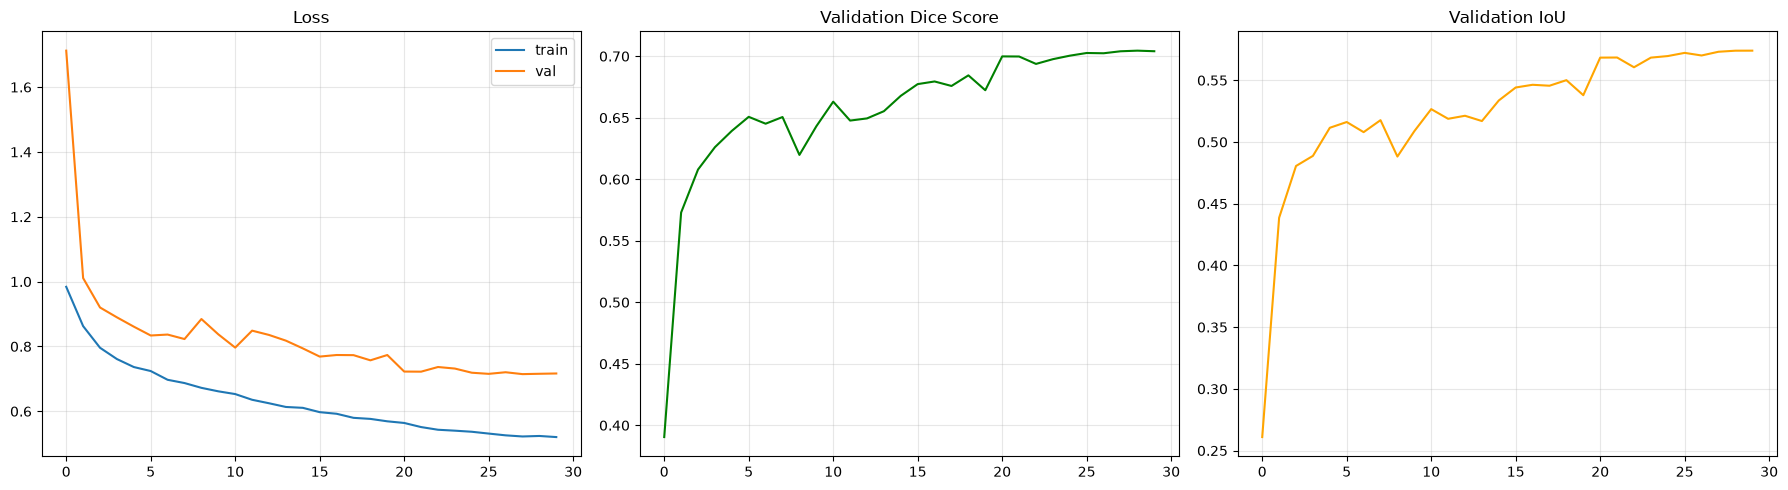

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(unet_history["train_loss"], label="train")
axes[0].plot(unet_history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(unet_history["val_dice"], color="green")
axes[1].set_title("Validation Dice Score"); axes[1].grid(alpha=0.3)

axes[2].plot(unet_history["val_iou"], color="orange")
axes[2].set_title("Validation IoU"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Loaded best U-Net (epoch 29, val Dice 0.7045)


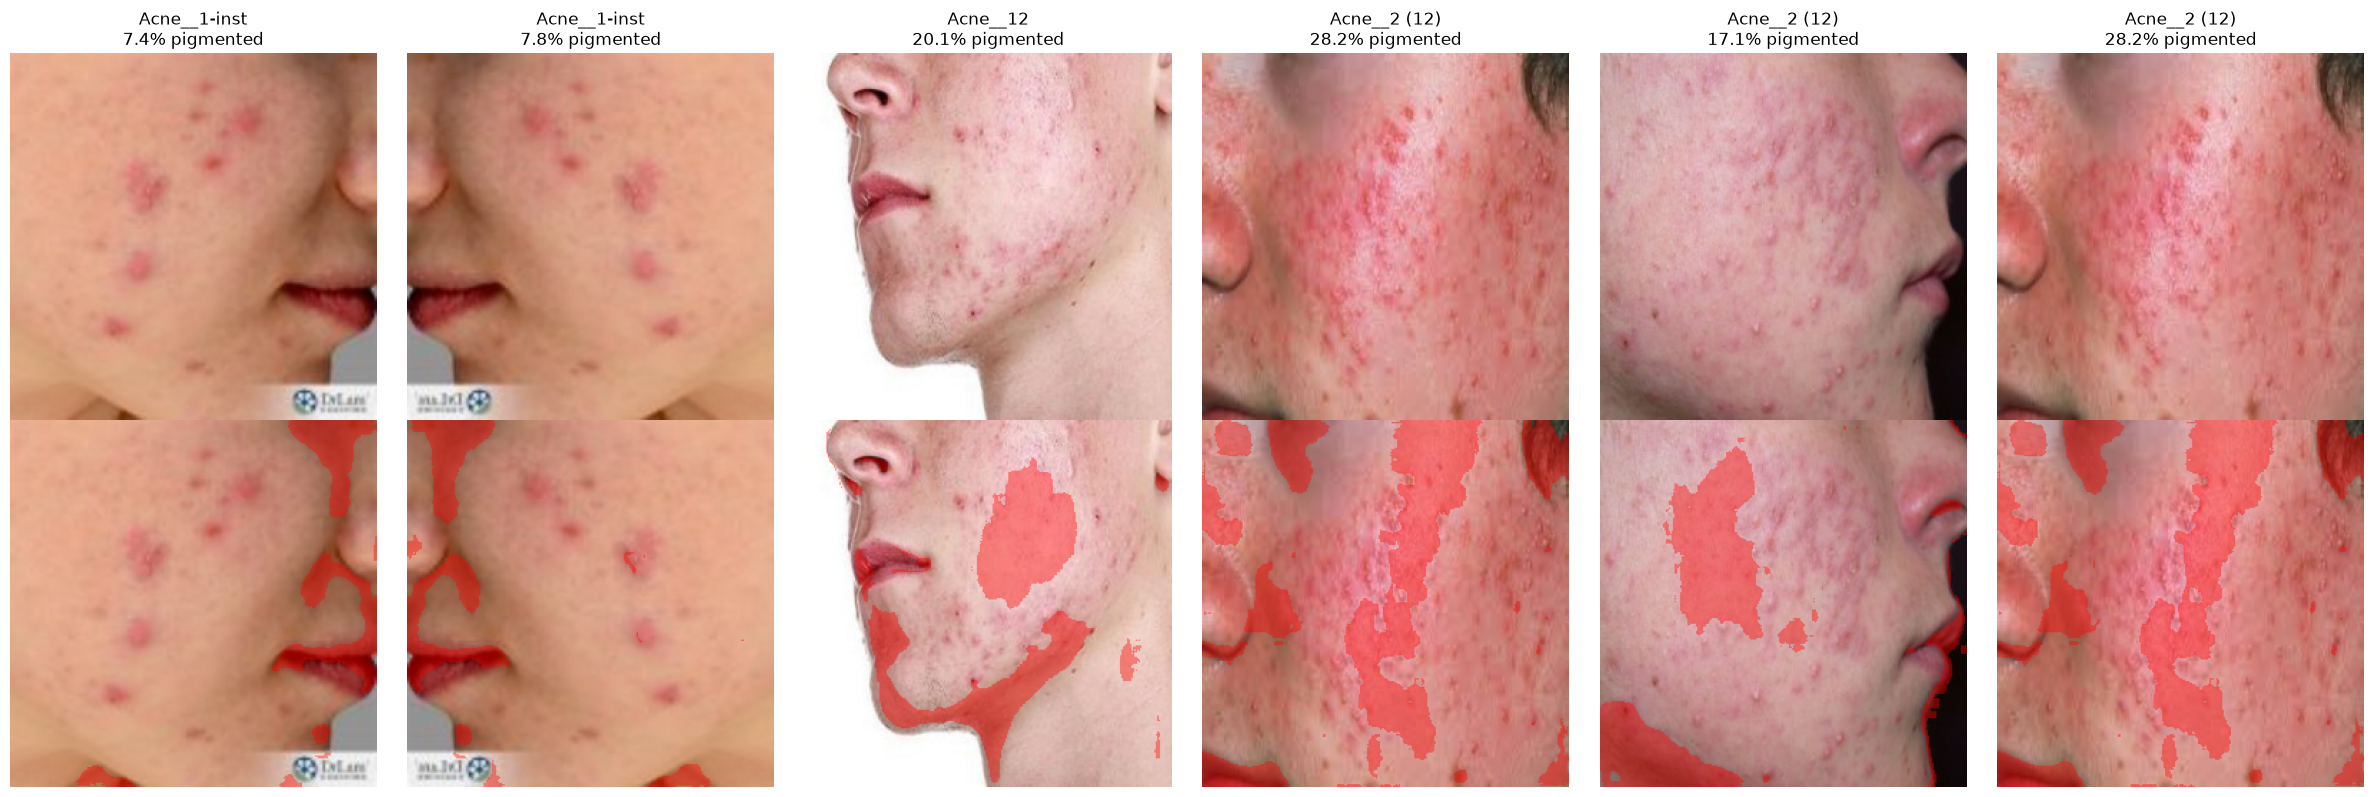

In [42]:
# ------------------------------------------------------------
# Load best U-Net weights (checkpoint is a dict, not a bare state_dict)
# ------------------------------------------------------------
checkpoint = torch.load(UNET_BEST_PATH, map_location=DEVICE, weights_only=True)
unet_model.load_state_dict(checkpoint["model_state_dict"])
unet_model.eval()
print(f"Loaded best U-Net (epoch {checkpoint['epoch']}, val Dice {checkpoint['best_val_dice']:.4f})")


def skin_mask_ycrcb(rgb_u8):
    """Rough skin-colour mask (YCrCb range). Returns a boolean array."""
    ycrcb = cv2.cvtColor(rgb_u8, cv2.COLOR_RGB2YCrCb)
    skin = cv2.inRange(ycrcb, (0, 133, 77), (255, 173, 127)) > 0
    # clean up speckles
    skin = cv2.morphologyEx(skin.astype(np.uint8), cv2.MORPH_OPEN, np.ones((5, 5), np.uint8)) > 0
    return skin


def predict_pigmentation_percentage(image_path, model, img_size=256, threshold=0.5,
                                    skin_only=True, min_skin_ratio=0.05):
    """
    Returns (resized RGB float image, binary pigment mask, percentage).
    percentage = pigmented pixels / skin pixels * 100.
    If almost no skin is detected (< min_skin_ratio of the image), or
    skin_only=False, it falls back to percentage of the whole image.
    """
    bgr = cv2.imread(str(image_path))
    if bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (img_size, img_size)).astype(np.float32) / 255.0

    tensor = torch.from_numpy(resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor)
        prob_mask = torch.sigmoid(pred)[0, 0].cpu().numpy()

    binary_mask = (prob_mask > threshold).astype(np.uint8)

    if skin_only:
        skin = skin_mask_ycrcb((resized * 255).astype(np.uint8))
        if skin.mean() >= min_skin_ratio:
            pigmented = (binary_mask > 0) & skin
            percentage = 100.0 * pigmented.sum() / skin.sum()
            return resized, pigmented.astype(np.uint8), percentage

    percentage = 100.0 * binary_mask.sum() / binary_mask.size
    return resized, binary_mask, percentage


sample_val_images = sorted((SEG_DIR / "images" / "val").glob("*.png"))[:6]
n = len(sample_val_images)
assert n > 0, "No validation images found - re-run the segmentation builder."

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), squeeze=False)

for i, img_path in enumerate(sample_val_images):
    resized, mask, pct = predict_pigmentation_percentage(img_path, unet_model)

    axes[0, i].imshow(resized)
    axes[0, i].set_title(f"{img_path.stem[:12]}\n{pct:.1f}% pigmented")
    axes[0, i].axis("off")

    overlay = resized.copy()
    overlay[mask == 1] = [1, 0, 0]
    blended = 0.6 * resized + 0.4 * overlay

    axes[1, i].imshow(blended)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### Batch report: pigmentation percentage for every validation image

In [43]:
# ============================================================
# BATCH REPORT: pigmentation percentage for every validation image
# ============================================================

val_img_dir = SEG_DIR / "images" / "val"
val_paths = sorted(val_img_dir.glob("*.png"))
assert len(val_paths) > 0, "No validation images found - re-run the segmentation builder."

report_rows = []
failed = []

for img_path in val_paths:
    try:
        _, _, pct = predict_pigmentation_percentage(img_path, unet_model)
    except Exception as e:
        failed.append((img_path.name, str(e)))
        continue

    # filenames are built as "<class>__<stem>_<ext>.png"
    class_name = img_path.stem.split("__")[0]

    report_rows.append({
        "filename": img_path.name,
        "class": class_name,
        "pigmentation_percentage": round(float(pct), 2),
    })

assert report_rows, "Every image failed - check the errors below:\n" + "\n".join(f"{n}: {e}" for n, e in failed[:5])

pigmentation_report_df = (
    pd.DataFrame(report_rows)
    .sort_values("pigmentation_percentage", ascending=False)
    .reset_index(drop=True)
)

print(f"Processed {len(report_rows)} images ({len(failed)} failed)")
display(pigmentation_report_df.head(20))

# Per-class summary (useful for your report)
class_summary = (
    pigmentation_report_df
    .groupby("class")["pigmentation_percentage"]
    .agg(images="count", mean="mean", median="median", max="max")
    .round(2)
    .sort_values("mean", ascending=False)
)
print("\nPigmentation % by class:")
display(class_summary)

# Save both files
REPORT_PATH = BASE_DIR / "pigmentation_report.csv"
SUMMARY_PATH = BASE_DIR / "pigmentation_class_summary.csv"

pigmentation_report_df.to_csv(REPORT_PATH, index=False)
class_summary.to_csv(SUMMARY_PATH)

print("\nSaved report  to", REPORT_PATH)
print("Saved summary to", SUMMARY_PATH)

if failed:
    print("\nFailed images (first 5):")
    for name, err in failed[:5]:
        print(" ", name, "->", err)

Processed 422 images (0 failed)


,filename,class,pigmentation_percentage
0,Nevus__ISIC_0000007.png,Nevus,91.79
1,Normal Skin__normal_-79-_jpg.rf.22f2ad87b72f8a...,Normal Skin,86.63
2,Nevus__ISIC_0000006.png,Nevus,83.32
3,Ringworm__0_FU-ringworm-38-_jpg.rf.2d5e3cf61e7...,Ringworm,79.50
4,Pigmented Benign Keratosis__ISIC_0024324.png,Pigmented Benign Keratosis,79.23
5,Nevus__ISIC_0000016.png,Nevus,75.72
6,Dyshidrotic Eczema__candidiasis-large-skin-fol...,Dyshidrotic Eczema,75.58
7,Pigmented Benign Keratosis__ISIC_0025066.png,Pigmented Benign Keratosis,75.44
8,Pigmented Benign Keratosis__ISIC_0026444.png,Pigmented Benign Keratosis,73.37
9,Dermato Fibroma__ISIC_0011677.png,Dermato Fibroma,73.18



Pigmentation % by class:


,images,mean,median,max
class,,,,
Dyshidrotic Eczema,40,32.34,30.24,75.58
Pigmented Benign Keratosis,40,31.77,24.48,79.23
Melanoma,40,30.92,26.33,70.62
Normal Skin,22,29.80,32.17,86.63
Chickenpox,8,28.83,30.02,44.90
Actinic Keratosis,40,25.75,22.77,65.20
Acne,38,24.14,24.38,42.80
Nevus,40,23.47,13.58,91.79
Nail Fungus,40,22.58,21.90,62.95



Saved report  to D:\nn\pigmentation_report.csv
Saved summary to D:\nn\pigmentation_class_summary.csv
